In [18]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.stats as sms
import statsmodels.api as sm

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
base = pio.templates["simple_white"]
custom_template = base.layout.template

custom_template.layout.update(
    margin=dict(l=50, r=50, t=20, b=50),
    xaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    yaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    colorscale=dict(
        sequential=px.colors.sequential.Inferno,
        diverging=px.colors.diverging.curl_r
    ),
    colorway=px.colors.qualitative.T10
)

pio.templates["tight"] = custom_template
pio.templates.default = "tight"

In [3]:
kc = pd.read_csv('kc_house_data.csv')

kc['date'] = pd.to_datetime(kc.date)

sqft_to_sqmeters = 0.09290303997

kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float,
                'yr_renovated': float, 'yr_built': float,
                'bedrooms': float, 'waterfront': float,
                'view': float, 'condition': float, 'grade': float})

kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan

In [4]:
kc_log = kc.copy()
kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']] = \
np.log10(kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']])

In [5]:
kc_log.yr_renovated = kc_log.yr_renovated.fillna(kc_log.yr_built)
kc_log.loc[:,'sqm_basement'] = kc_log.loc[:,'sqm_basement'].fillna(0)
kc.yr_renovated = kc.yr_renovated.fillna(kc.yr_built)
kc.loc[:,'sqm_basement'] = kc.loc[:,'sqm_basement'].fillna(0)

In [6]:
kc_z=kc.copy()
kc_log_z=kc_log.copy()
for col in kc_z.drop(columns=['id', 'date']).columns:
    kc_z.loc[:,col] = st.zscore(kc_z.loc[:,col])
    kc_log_z.loc[:,col] = st.zscore(kc_log_z.loc[:,col])

In [7]:
kc_pca = kc_z.drop(columns=['id', 'date', 'price', 'lat', 'long']).copy()
kc_log_pca = kc_log_z.drop(columns=['id', 'date', 'price', 'lat', 'long']).copy()

##### K-Means clustering

In [ ]:
kmeans = KMeans(n_clusters = 1, init = 'k-means++', max_iter = 300, n_init = 1, random_state = 42)
kmeans_df = pd.DataFrame(data=0.0, columns=range(1, 16), index=['n_clusters','inertia', 'silhouette'])
for i in range(1,16):
    kmeans.n_clusters = i
    kmeans.fit(kc_log_pca)
    kmeans_df.loc['n_clusters', i] = i
    kmeans_df.loc['inertia', i] = kmeans.inertia_ # Sum of squared distances of samples to closest cluster center
    if(i>1):
        kmeans_df.loc['silhouette', i] = silhouette_score(kc_log_pca, kmeans.labels_)
    else:
        kmeans_df.loc['silhouette', i] = 0
kmeans_df

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
n_clusters,1.0,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,15.000000
inertia,324195.0,245786.345489,215712.158447,191801.229235,180087.849224,158638.928581,150138.267779,138333.764209,130949.743095,123564.415095,119725.777555,116671.154293,112781.179207,111165.127289,108494.765864
silhouette,0.0,0.242931,0.198734,0.206878,0.202183,0.200601,0.197608,0.208440,0.199219,0.194212,0.176203,0.176011,0.168163,0.166221,0.167275


In [31]:
px.line(kmeans_df.T, x='n_clusters', y='inertia', width=750, height=200)

In [32]:
px.line(kmeans_df.T, x='n_clusters', y='silhouette', width=750, height=200)

In [134]:
kc_log_z.describe().T

,count,mean,min,25%,50%,75%,max,std
id,21613.0,4580301520.864988,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0,2876565571.312057
date,21613,2014-10-29 04:38:01.959931648,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21613.0,-0.0,-3.460545,-0.694294,-0.058507,0.625035,5.333324,1.000023
floors,21613.0,-0.0,-0.915427,-0.915427,0.010539,0.936506,3.714405,1.000023
bedrooms,21613.0,0.0,-3.624404,-0.398737,-0.398737,0.676485,31.857929,1.000023
bathrooms,21613.0,-0.0,-2.74592,-0.473621,0.175607,0.500221,7.64173,1.000023
yr_built,21613.0,0.0,-2.417383,-0.681079,0.136006,0.885,1.497813,1.000023
yr_renovated,21613.0,0.0,-2.547578,-0.672981,0.125459,0.889183,1.44462,1.000023
waterfront,21613.0,0.0,-0.087173,-0.087173,-0.087173,-0.087173,11.47149,1.000023
view,21613.0,0.0,-0.305759,-0.305759,-0.305759,-0.305759,4.914129,1.000023


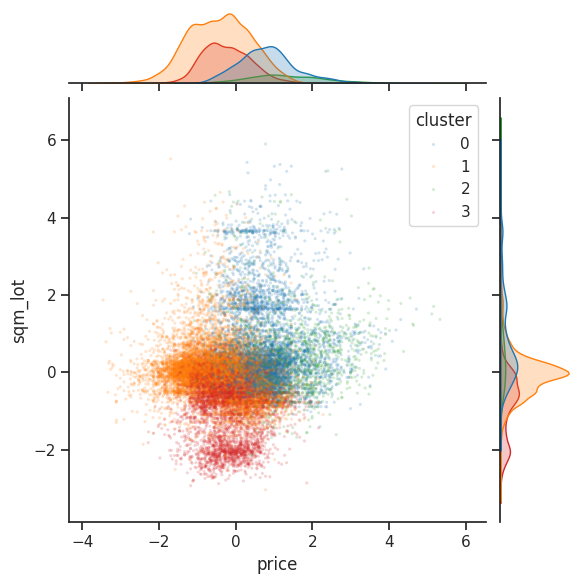

In [162]:
kmeans.n_clusters = 4
kmeans.fit(kc_log_z.drop(columns=['id', 'date', 'bedrooms', 'waterfront', 'lat', 'long']))
cluster_df = kc_log_z.drop(columns=['id', 'date', 'bedrooms', 'waterfront', 'lat', 'long']).copy()
cluster_df['cluster'] = kmeans.labels_
sns.jointplot(cluster_df, x='price', y='sqm_lot', hue='cluster', palette='tab10', s=5, lw=0, alpha=0.2)

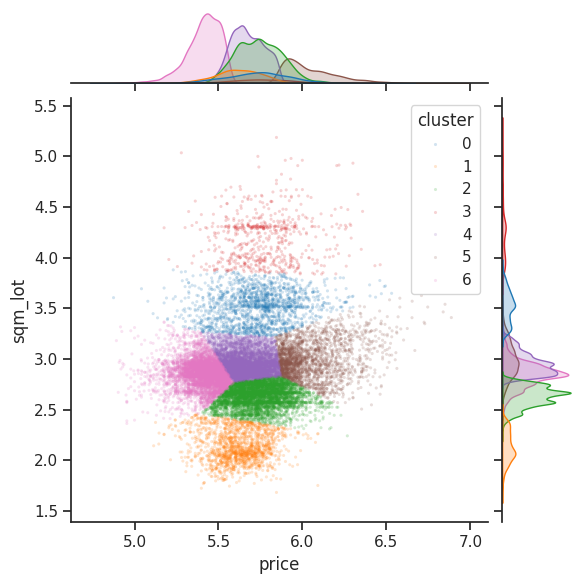

In [101]:
kmeans.n_clusters = 7
kmeans.fit(kc_log[['price', 'sqm_lot']])
cluster_df = kc_log[['price', 'sqm_lot']].copy()
cluster_df['cluster'] = kmeans.labels_
sns.jointplot(cluster_df, x='price', y='sqm_lot', hue='cluster', palette='tab10', s=5, lw=0, alpha=0.2)

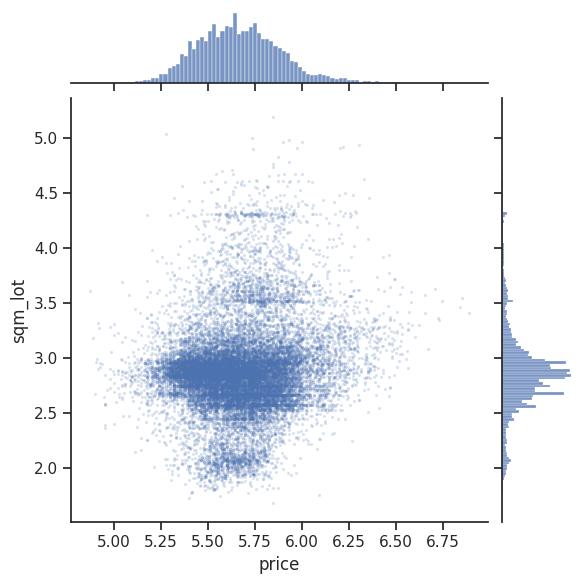

In [ ]:
sns.jointplot(kc_log, x='price', y='sqm_lot', s=5, lw=0, alpha=0.2)

<Axes: xlabel='sqm_lot', ylabel='Count'>

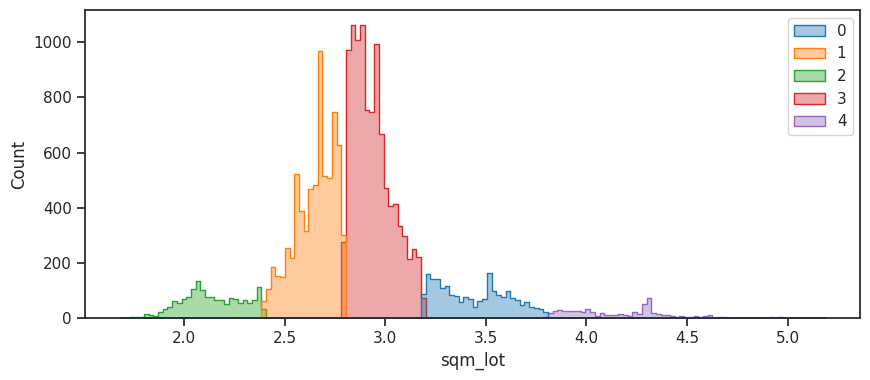

In [81]:
kmeans.n_clusters = 5
kmeans.fit(kc_log.sqm_lot.values.reshape(-1, 1))
cluster_df = kc_log[['sqm_living', 'sqm_lot']].copy()
cluster_df['cluster'] = kmeans.labels_
sns.set(rc={"figure.figsize":(10,4)})
sns.set_style('ticks')
sns.histplot(cluster_df, x='sqm_lot', hue=kmeans.labels_, palette='tab10',
             multiple='layer', element='step', alpha=0.4, linewidth=1)

In [8]:
pca = PCA()
pca.fit(kc_pca)
log_pca = PCA()
log_pca.fit(kc_log_pca)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [9]:
px.line(x=range(1, len(pca.explained_variance_ratio_) + 1),
        y=[pca.explained_variance_ratio_.round(2)*100,
        pca.explained_variance_ratio_.round(2).cumsum()*100], markers=True)

In [10]:
px.line(x=range(1, len(log_pca.explained_variance_ratio_) + 1),
        y=[log_pca.explained_variance_ratio_.round(2)*100,
        log_pca.explained_variance_ratio_.round(2).cumsum()*100], markers=True)

In [11]:
pca2 = PCA(2).fit(kc_pca)
pca3 = PCA(3).fit(kc_pca)
pca6 = PCA(6).fit(kc_pca)
pca14 = PCA(14).fit(kc_pca)
log_pca2 = PCA(2).fit(kc_log_pca)
log_pca3 = PCA(3).fit(kc_log_pca)
log_pca6 = PCA(6).fit(kc_log_pca)
log_pca14 = PCA(14).fit(kc_log_pca)

In [12]:
px.imshow(pd.DataFrame(np.round(pca3.components_, 2), columns=list(kc_pca.columns)),
          text_auto=True, color_continuous_scale=px.colors.diverging.Picnic_r,
          color_continuous_midpoint=0)

In [13]:
px.imshow(pd.DataFrame(np.round(log_pca3.components_, 2), columns=list(kc_log_pca.columns)),
          text_auto=True, color_continuous_scale=px.colors.diverging.Picnic_r,
          color_continuous_midpoint=0)

In [14]:
px.imshow(pd.DataFrame(np.round(pca14.components_, 2), columns=list(kc_pca.columns)),
          text_auto=True, color_continuous_scale=px.colors.diverging.Picnic_r,
          color_continuous_midpoint=0)

In [15]:
pd.DataFrame(np.round(pca14.components_, 2), columns=list(kc_pca.columns)).apply(sum, axis=1)

0     3.200000e+00
1     1.180000e+00
2     6.800000e-01
3     5.500000e-01
4     2.900000e-01
5     1.440000e+00
6    -4.163336e-17
7     2.300000e-01
8     7.000000e-02
9     2.200000e-01
10   -5.200000e-01
11   -5.000000e-02
12   -1.600000e-01
13    2.775558e-17
dtype: float64

In [16]:
pca14.explained_variance_

array([5.35974773, 2.22750834, 1.67494934, 1.27441504, 0.93805205,
       0.74086568, 0.6682061 , 0.55492158, 0.47700489, 0.28649243,
       0.26050138, 0.24194056, 0.20920721, 0.08688172])

In [17]:
pca14.explained_variance_ratio_.sum()

np.float64(1.0000000000000002)

In [18]:
pca14.mean_

array([-5.26011371e-17,  2.41965231e-16, -1.47283184e-16,  1.92520162e-15,
        8.41618194e-16,  3.28757107e-18,  1.31502843e-18, -2.47225345e-16,
        2.36705117e-16, -3.34017221e-16, -1.31502843e-18,  3.57687733e-16,
       -3.81358244e-17,  1.51228269e-16,  2.63005686e-18])

In [19]:
pca14.noise_variance_

np.float64(1.8648178414222952e-17)

In [20]:
pca14.singular_values_

array([340.34521889, 219.41036966, 190.26036167, 165.95980792,
       142.38392118, 126.53690755, 120.17183588, 109.51239735,
       101.53339202,  78.6871937 ,  75.03303227,  72.3105752 ,
        67.24125339,  43.33229492])

In [21]:
pca14.score(kc_pca) # log-likelihood

-inf

In [22]:
pca6.score(kc_pca)

-17.442680139916362

In [23]:
pca6.score_samples(kc_pca) # log-likelihood per sample

array([-12.09529635, -14.93978738, -18.66144581, ..., -16.74704978,
       -12.22274993, -16.65375737], shape=(21613,))